Code to plot the location of vortex ring cores during formation for a range of conditions.

These plots should be similar to Didden figure 5

Plots to make:
r against z
r against t
z against t
normalised injection time like I did for circulation
core expansion rate - so that I can later define some Rossby criterion.

In [78]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()
print(plt.rcParams["figure.dpi"])


h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')

vels = h5file['Narrow']['U50']['L50']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
u, v = u/0.1, v/0.1 
r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])
Time = oj.frames_to_seconds(u, v, 90)
h5file.close()

VortLocMax, VortLocMin = oj.vorticityPeakTracking_inter(u[:,:,:], v[:,:,:]) # Axis 0 is radial, axis 1 is axial
#normalise location about the axis of rotation
VortLocMin[:,0] = np.subtract(VortLocMin[:,0], int(u.shape[1]/2))
VortLocMax[:,0] = np.subtract(VortLocMax[:,0], int(u.shape[1]/2))


C:/Coding
Thesis plot settings applied
400.0


Initial plot to show what it looks like:
two cores 

2.7148
27.442168852217474


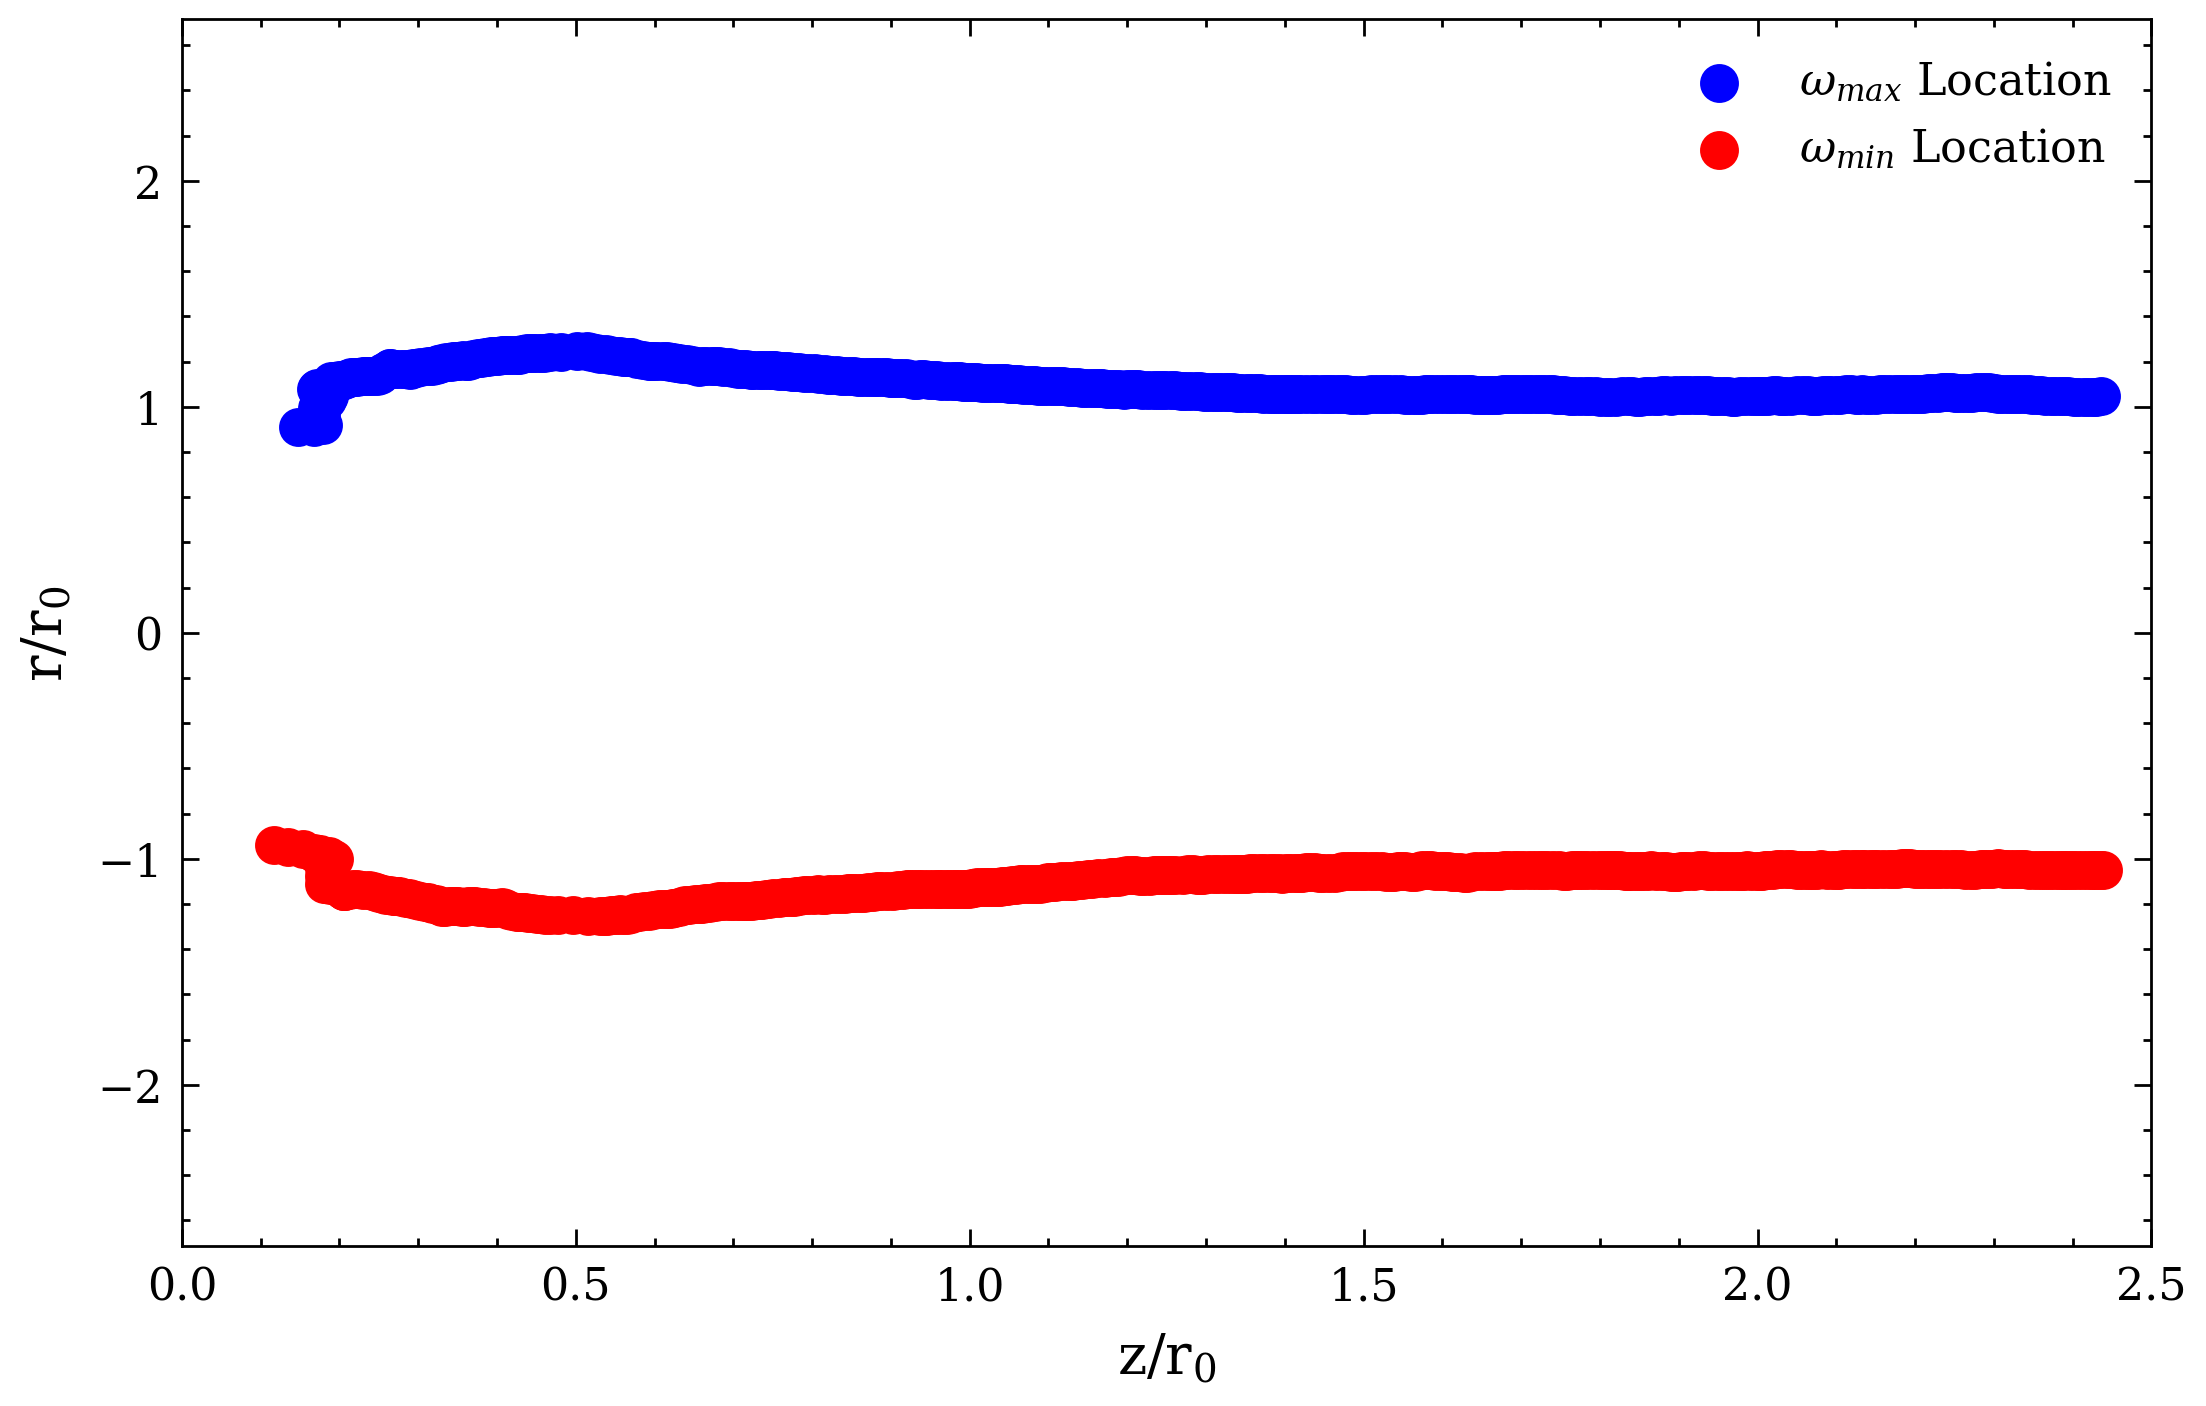

In [79]:

# f1, ax1 = plt.subplots(1, 1, figsize=(5.5, 3.5))
# ax1.scatter(Time[81:530]-8/9, VortLocMax[81:530,0], label=r'$\omega_{max}$ Location', color='b')
# ax1.scatter(Time[81:530]-8/9, VortLocMin[81:530,0], label=r'$\omega_{min}$ Location', color='r')
# ax1.set_xlabel('Time (s)')
# ax1.set_ylabel('r')
# ax1.legend(fontsize=8)
# plt.show()

print(r_nd[-1])
r_factor = u.shape[1]/(2*r_nd[-1])
print(r_factor)

f2, ax2 = plt.subplots(1, 1, figsize=(5.5, 3.5))
ax2.scatter(VortLocMax[81:530,1]/r_factor-1, VortLocMax[81:530,0]/r_factor, label=r'$\omega_{max}$ Location', color='b')
ax2.scatter(VortLocMin[81:530,1]/r_factor-1, VortLocMin[81:530,0]/r_factor, label=r'$\omega_{min}$ Location', color='r')
# ax2.scatter(VortLocMax[81:,1]/r_factor-1, VortLocMax[81:,0]/r_factor, label=r'$\omega_{max}$ ', color='b')
# ax2.scatter(VortLocMin[81:,1]/r_factor-1, VortLocMin[81:,0]/r_factor, label=r'$\omega_{min}$ ', color='r')
ax2.set_ylim(-2.7148, 2.7148)
ax2.set_xlim(0, 2.5)
ax2.set_xlabel(r'z/r$_{0}$')
ax2.set_ylabel(r'r/r$_{0}$')
ax2.legend(fontsize=8)
plt.show()

show the comparison of the two absolute values 

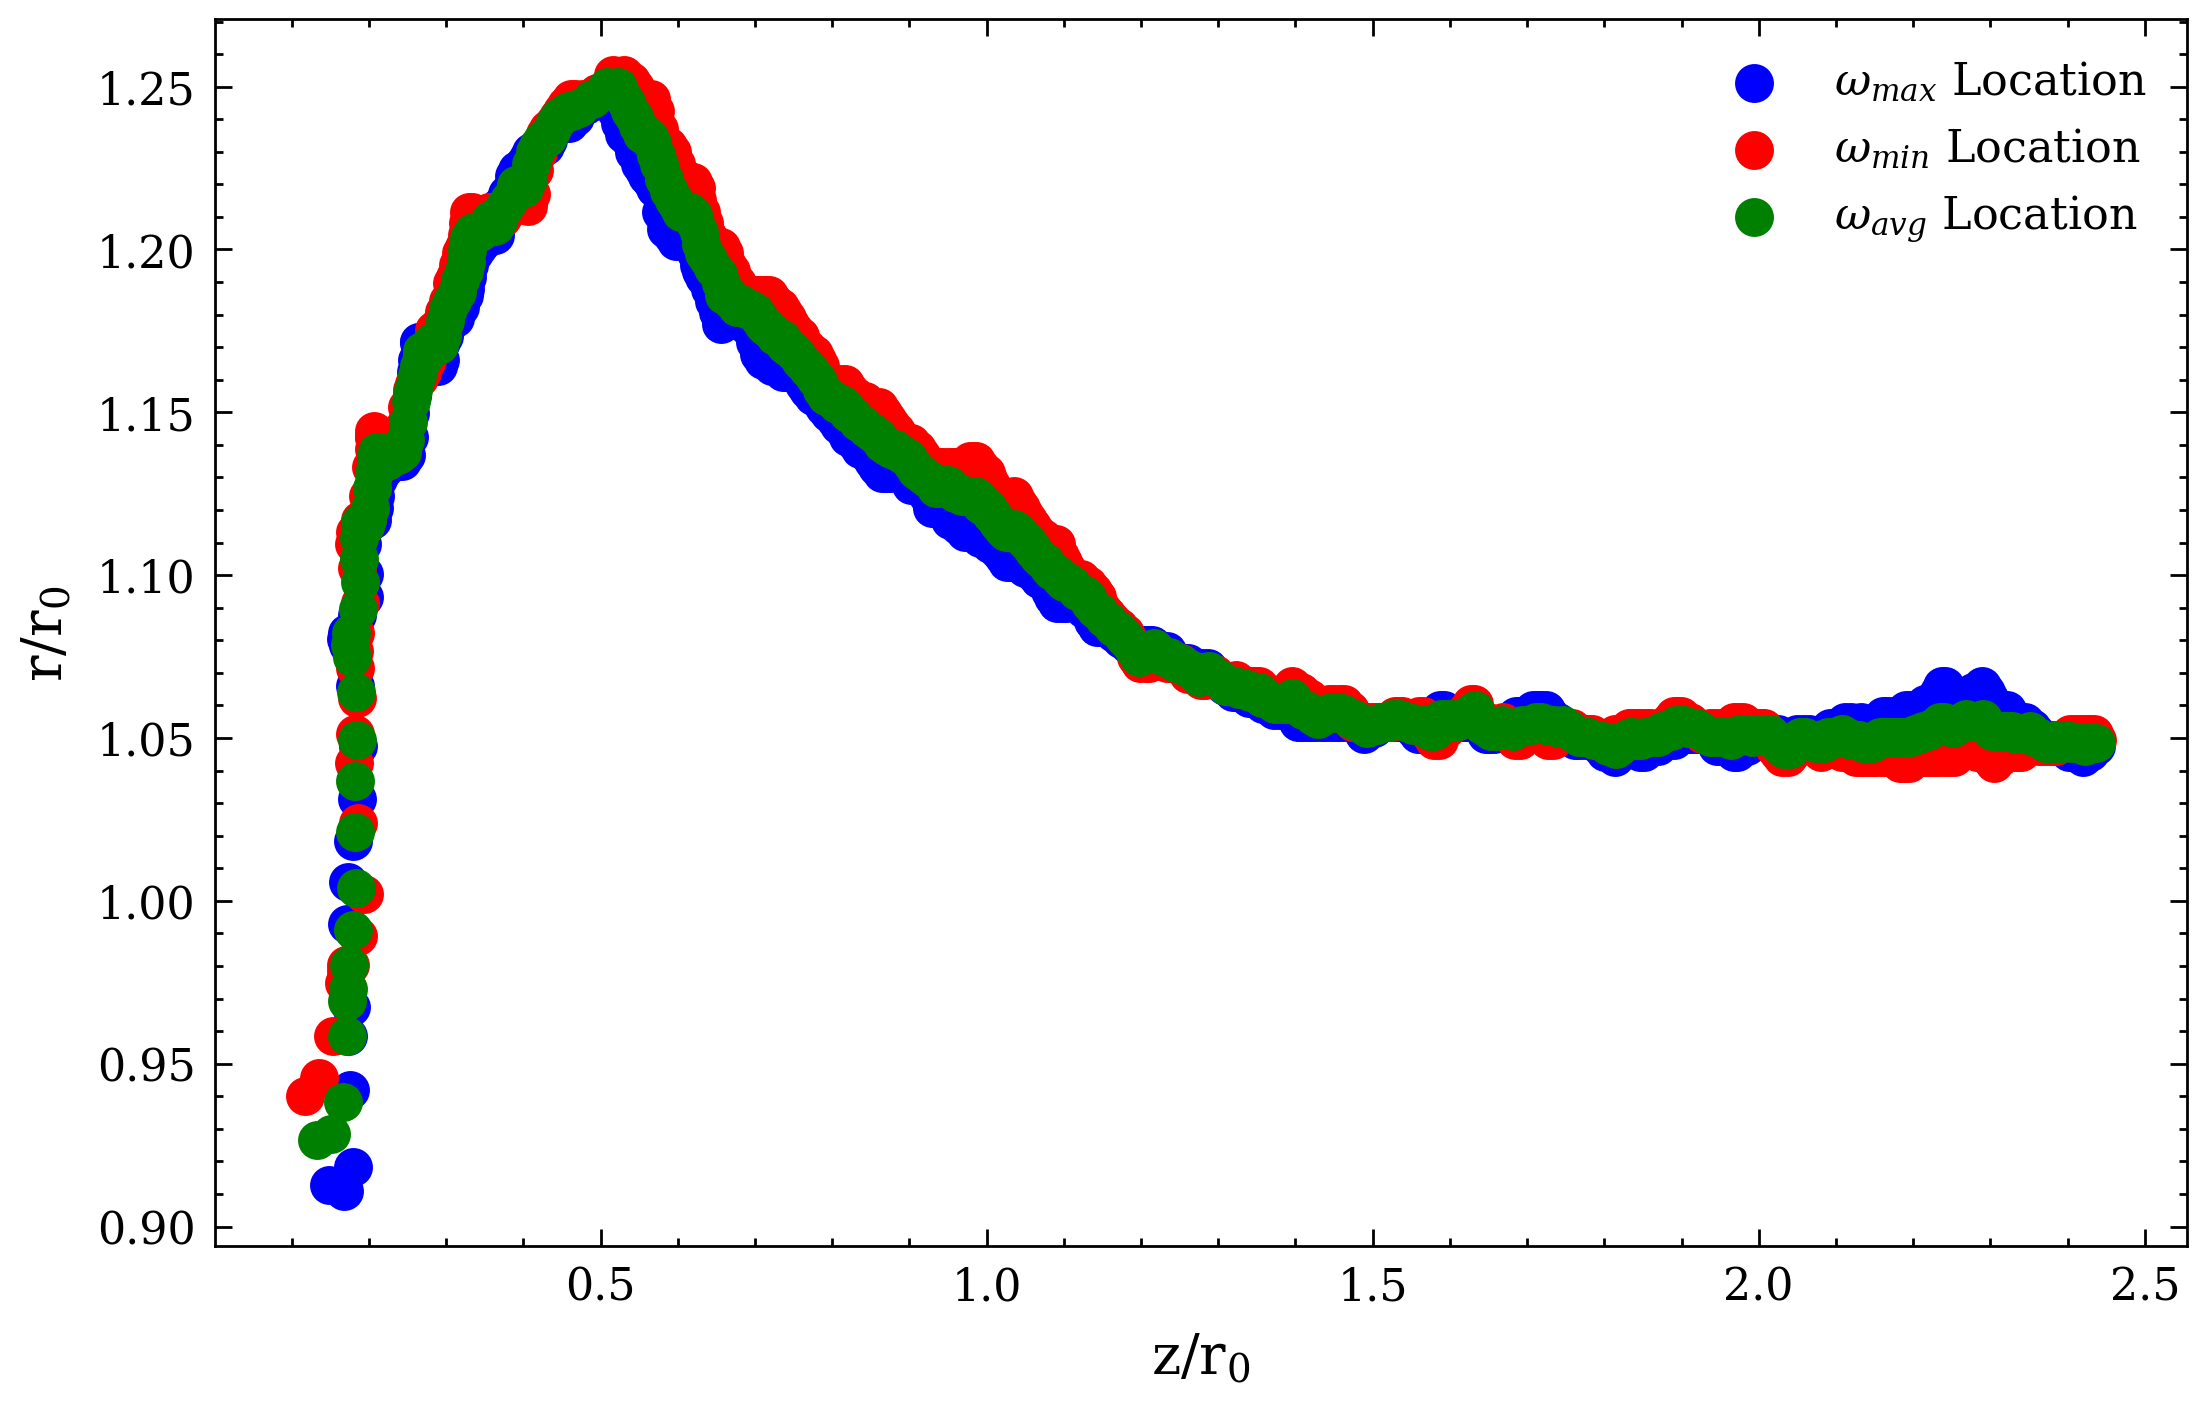

In [80]:
VortLocMin = abs(VortLocMin)
VortLocAvg = np.mean([VortLocMax, VortLocMin], axis = 0)


f2, ax2 = plt.subplots(1, 1, figsize=(5.5, 3.5))
ax2.scatter(VortLocMax[81:530,1]/r_factor-1, VortLocMax[81:530,0]/r_factor, label=r'$\omega_{max}$ Location', color='b')
ax2.scatter(VortLocMin[81:530,1]/r_factor-1, VortLocMin[81:530,0]/r_factor, label=r'$\omega_{min}$ Location', color='r')
ax2.scatter(VortLocAvg[81:530,1]/r_factor-1, VortLocAvg[81:530,0]/r_factor, label=r'$\omega_{avg}$ Location', color='g')
ax2.set_xlabel(r'z/r$_{0}$')
ax2.set_ylabel(r'r/r$_{0}$')
ax2.legend(fontsize=8)
plt.show()

Now to plot the averages of different conditions against each other:

use length test data here to get more conditions

the argument at the end of this will be that we can normalise by injection time maybe????

In [83]:
# h5file = h5py.File('E:/H5/LengthTestNEW.h5', 'r')
h5file = h5py.File('E:/H5/LengthTest.h5', 'r')
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')

vels = h5file['Narrow']['U100']['L50']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
u, v = u/0.1, v/0.1 
r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])
Time = oj.frames_to_seconds(u, v, 90)
h5file.close()

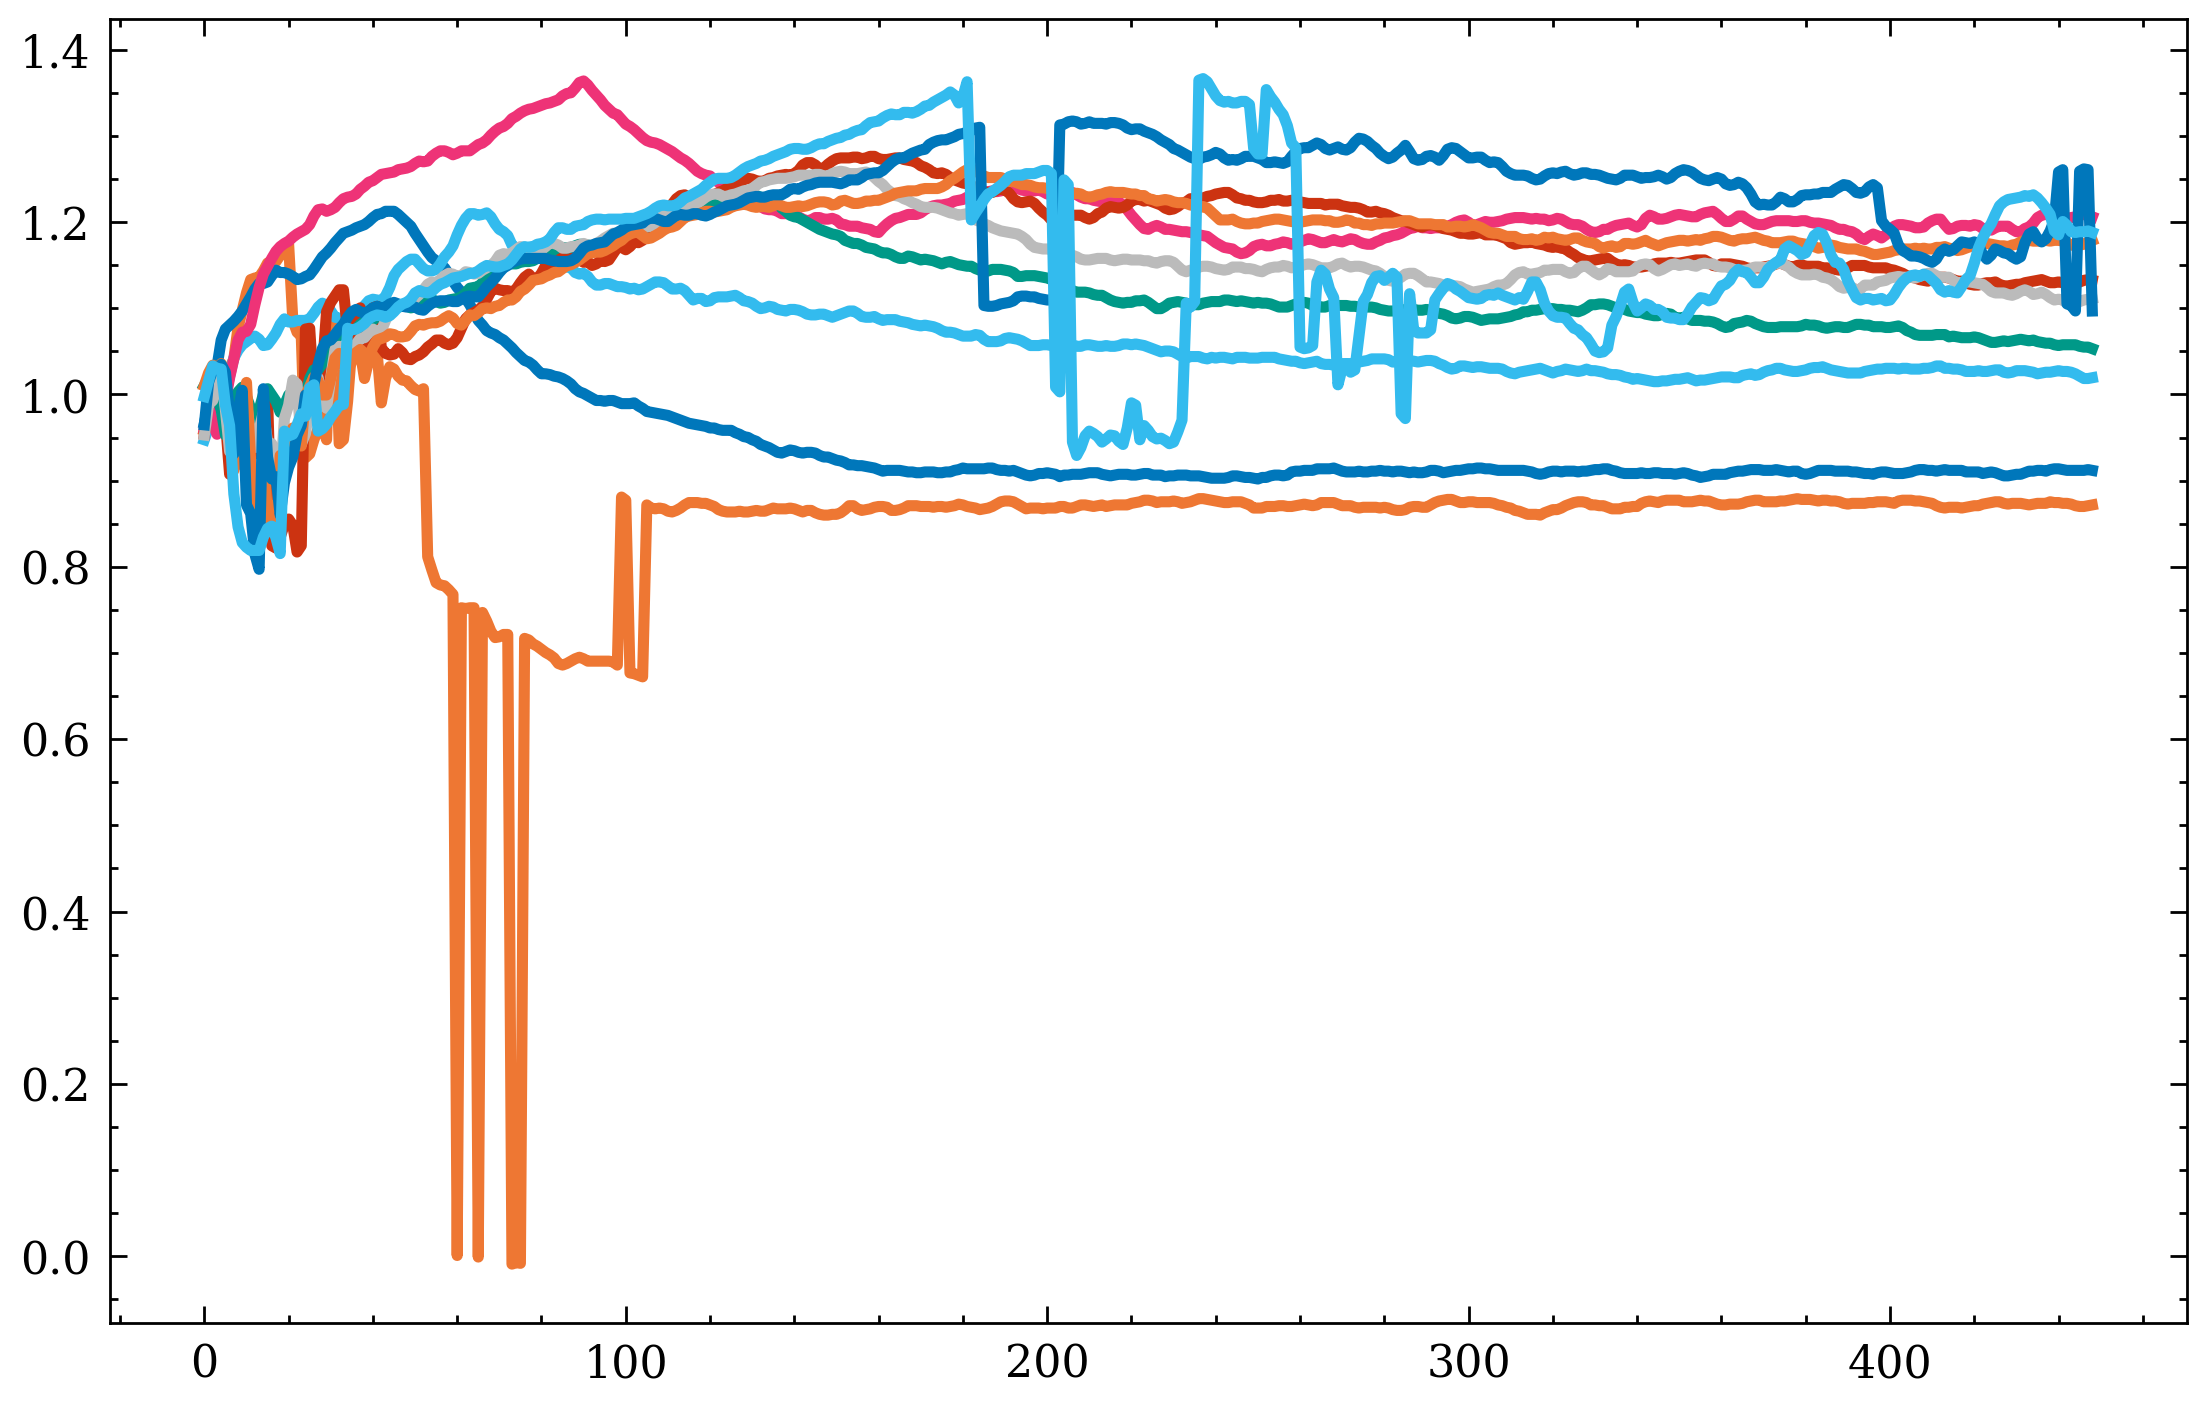

In [107]:
lengths = np.array([25, 50, 75, 100, 125, 150, 175, 200, 225, 240])
h5file = h5py.File('E:/H5/LengthTest.h5', 'r')
# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# lengths = np.array([50, 100])
# oj.descend_obj(h5file)

index = 0

fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))


for length in lengths:

    # vels = h5file['Narrow']['U100'][f'L{str(lengths[index])}']['RPM0']
    vels = h5file['Narrow']['U100'][f'L{str(lengths[index])}']['RPM0']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
    VortLocMax, VortLocMin = oj.vorticityPeakTracking_inter(u[:,:,:], v[:,:,:]) # Axis 0 is radial, axis 1 is axial
    #normalise location about the axis of rotation
    VortLocMin[:,0] = abs(np.subtract(VortLocMin[:,0], int(u.shape[1]/2)))
    VortLocMax[:,0] = np.subtract(VortLocMax[:,0], int(u.shape[1]/2))
    VortLocAvg = np.mean([VortLocMax, VortLocMin], axis = 0)
    index += 1
    print(index)
    ax.plot(VortLocAvg[81:530,0]/r_factor, label=r'$\omega_{max}$ Location')

plt.show()